# CS2 Role Clustering: Ablation Analysis

This notebook consolidates the ablation workflow that was previously split across:

- `ablation.py`
- `ablation_plotter.py`
- `inspect_ablations.py`

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler


## Configuration

Change these paths or settings only if the project layout changes.


In [6]:
INPUT_PATH = Path("output.csv")
GT_PATH = Path("liquipedia_player_roles.csv")

ABLATION_OUTPUT_DIR = Path("outputs/ablations")
ABLATION_PLOTS_DIR = Path("plots/ablations")
INSPECTION_OUTPUT_DIR = Path("outputs/ablations/cluster_inspection")
INSPECTION_PLOTS_DIR = Path("plots/ablations/cluster_inspection")

SIDES = ["ct", "t"]
RANDOM_STATE = 69420
K_VALUES = [3, 4, 5, 6, 7, 8]
N_BOOTS = 50
RESAMPLE_FRAC = 0.80

META_COLS = {"player_name", "side", "rounds_played"}

FEATURE_GROUPS = {
    "combat": [
        "survival_rate",
        "damage_per_round",
        "damage_taken_per_round",
        "damage_diff_per_round",
        "multi_kill_rate",
        "rifle_kill_share",
        "awp_kill_share",
    ],
    "opening_aggression": [
        "opening_kill_rate",
        "opening_death_rate",
        "opening_duel_success",
        "first_contact_rate",
        "time_near_enemy_rate",
    ],
    "trading_teamwork": [
        "trade_kill_rate",
        "death_traded_rate",
        "trade_participation",
        "assists_per_round",
        "flash_assists_per_round",
    ],
    "utility": [
        "grenades_per_round",
        "he_grenades_per_round",
        "flashbangs_per_round",
        "smokes_per_round",
        "fire_nades_per_round",
        "util_damage_per_round",
    ],
    "positioning_movement": [
        "avg_distance_to_enemy",
        "avg_distance_to_team_centroid",
        "relative_team_centroid_distance",
        "avg_distance_moved_per_round",
        "avg_distance_to_closest_teammate",
        "time_stationary_rate",
    ],
}

METRIC_COLS = [
    "composite_score",
    "gt_ari",
    "gt_purity",
    "stability_mean",
    "silhouette",
]

DISPLAY_NAMES = {
    "composite_score": "Composite Score",
    "gt_ari": "Ground-Truth ARI",
    "gt_purity": "Ground-Truth Purity",
    "stability_mean": "Bootstrap Stability",
    "silhouette": "Silhouette Score",
}


## Data and ground-truth helpers


In [7]:
def load_data() -> pd.DataFrame:
    df = pd.read_csv(INPUT_PATH).fillna(0)
    required = {"player_name", "side", "rounds_played"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    df["side"] = df["side"].str.lower()
    return df[df["side"].isin(SIDES)].copy()


def load_ground_truth() -> pd.DataFrame | None:
    if not GT_PATH.exists():
        return None
    gt = pd.read_csv(GT_PATH).fillna("")
    gt["_key"] = gt["player_page"].str.lower().str.strip()
    return gt


def add_ground_truth(df: pd.DataFrame, gt: pd.DataFrame | None) -> pd.DataFrame:
    if gt is None:
        out = df.copy()
        out["gt_role_1"] = ""
        out["gt_role_2"] = ""
        return out

    out = df.copy()
    out["_key"] = out["player_name"].str.lower().str.strip()
    out = out.merge(
        gt[["_key", "role_1", "role_2"]].rename(
            columns={"role_1": "gt_role_1", "role_2": "gt_role_2"}
        ),
        on="_key",
        how="left",
    ).drop(columns=["_key"])
    out[["gt_role_1", "gt_role_2"]] = out[["gt_role_1", "gt_role_2"]].fillna("")
    return out


def valid_role(role: str) -> bool:
    return str(role).strip().lower() not in {"", "unknown"}


def resolve_gt_labels(df: pd.DataFrame, labels: np.ndarray) -> pd.Series:
    work = df.copy()
    work["_cluster"] = labels
    cluster_majorities = {}

    for cluster_id, group in work.groupby("_cluster"):
        if cluster_id == -1:
            continue
        counts = {}
        for col in ["gt_role_1", "gt_role_2"]:
            for role in group[col]:
                if valid_role(role):
                    counts[role] = counts.get(role, 0) + 1
        if counts:
            cluster_majorities[cluster_id] = max(counts, key=counts.get)

    resolved = []
    for _, row in work.iterrows():
        cid = row["_cluster"]
        majority = cluster_majorities.get(cid)
        r1 = row.get("gt_role_1", "")
        r2 = row.get("gt_role_2", "")

        if majority is not None:
            if str(r1).strip().lower() == majority.strip().lower():
                resolved.append(r1)
                continue
            if str(r2).strip().lower() == majority.strip().lower():
                resolved.append(r2)
                continue

        if valid_role(r1):
            resolved.append(r1)
        elif valid_role(r2):
            resolved.append(r2)
        else:
            resolved.append("")

    return pd.Series(resolved, index=df.index)


def gt_metrics(df: pd.DataFrame, labels: np.ndarray) -> tuple[float, float]:
    if "gt_role_1" not in df.columns:
        return np.nan, np.nan

    resolved = resolve_gt_labels(df, labels)
    mask = resolved.apply(valid_role) & (labels != -1)

    if mask.sum() < 2 or resolved[mask].nunique() < 2:
        return np.nan, np.nan

    encoded = LabelEncoder().fit_transform(resolved[mask])
    gt_ari = adjusted_rand_score(encoded, labels[mask])

    temp = pd.DataFrame({"cluster": labels[mask], "role": resolved[mask]})
    total_match = 0
    total_count = 0
    for _, group in temp.groupby("cluster"):
        total_match += group["role"].value_counts().max()
        total_count += len(group)

    purity = total_match / total_count if total_count > 0 else np.nan
    return gt_ari, purity


## Ablation experiment runner


In [8]:
def all_feature_columns(df: pd.DataFrame) -> list[str]:
    return [
        c for c in df.columns
        if c not in META_COLS
        and not c.startswith("gt_")
        and pd.api.types.is_numeric_dtype(df[c])
        and df[c].nunique() > 1
    ]


def make_experiments(df: pd.DataFrame) -> dict[str, list[str]]:
    all_features = all_feature_columns(df)
    groups = {
        name: [c for c in cols if c in all_features]
        for name, cols in FEATURE_GROUPS.items()
    }
    std_features = [c for c in all_features if c.endswith("_std")]

    experiments = {"full": all_features}
    for group_name, cols in groups.items():
        experiments[f"{group_name}_only"] = cols
        experiments[f"no_{group_name}"] = [c for c in all_features if c not in set(cols)]

    experiments["consistency_only"] = std_features
    experiments["no_consistency"] = [c for c in all_features if c not in set(std_features)]

    weapon_cols = {"awp_kill_share", "rifle_kill_share"}
    experiments["no_weapon_share"] = [c for c in all_features if c not in weapon_cols]

    tactical_cols = (
        groups["opening_aggression"]
        + groups["trading_teamwork"]
        + groups["utility"]
        + groups["positioning_movement"]
    )
    experiments["tactics_only"] = sorted(set(tactical_cols))

    return {name: cols for name, cols in experiments.items() if len(cols) >= 2}


def bootstrap_stability(X_scaled: np.ndarray, full_labels: np.ndarray, k: int) -> tuple[float, float]:
    rng = np.random.RandomState(RANDOM_STATE)
    n = X_scaled.shape[0]
    sample_size = max(3, int(n * RESAMPLE_FRAC))
    scores = []

    for i in range(N_BOOTS):
        idx = rng.choice(n, size=sample_size, replace=True)
        boot_labels = KMeans(n_clusters=k, random_state=RANDOM_STATE + i, n_init=20).fit_predict(X_scaled[idx])
        ref_labels = full_labels[idx]
        if len(set(ref_labels)) < 2 or len(set(boot_labels)) < 2:
            continue
        scores.append(adjusted_rand_score(ref_labels, boot_labels))

    if len(scores) < 5:
        return np.nan, np.nan
    return float(np.mean(scores)), float(np.std(scores))


def run_ablation_for_side(df: pd.DataFrame, side: str, gt: pd.DataFrame | None) -> pd.DataFrame:
    side_df = df[df["side"] == side].reset_index(drop=True)
    side_df = add_ground_truth(side_df, gt)
    experiments = make_experiments(side_df)
    rows = []

    for ablation_name, features in experiments.items():
        X = side_df[features].apply(pd.to_numeric, errors="coerce").fillna(0)
        X = X.loc[:, X.nunique() > 1]
        if X.shape[1] < 2:
            continue

        X_scaled = StandardScaler().fit_transform(X)
        for k in K_VALUES:
            if k >= len(side_df):
                continue

            labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit_predict(X_scaled)
            sil = silhouette_score(X_scaled, labels)
            db = davies_bouldin_score(X_scaled, labels)
            stability_mean, stability_std = bootstrap_stability(X_scaled, labels, k)
            gt_ari, gt_purity = gt_metrics(side_df, labels)

            composite = (
                0.40 * sil
                + 0.20 * (1 / (1 + db))
                + 0.40 * max(0, stability_mean - stability_std)
            )

            rows.append({
                "side": side,
                "ablation": ablation_name,
                "k": k,
                "n_features": X.shape[1],
                "features": ", ".join(X.columns),
                "silhouette": sil,
                "davies_bouldin": db,
                "stability_mean": stability_mean,
                "stability_std": stability_std,
                "gt_ari": gt_ari,
                "gt_purity": gt_purity,
                "composite_score": composite,
            })

    return pd.DataFrame(rows)


def run_all_ablations() -> tuple[pd.DataFrame, pd.DataFrame]:
    ABLATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    df = load_data()
    gt = load_ground_truth()
    all_results = []

    for side in SIDES:
        print(f"[run] ablations for {side.upper()}")
        results = run_ablation_for_side(df, side, gt)
        side_dir = ABLATION_OUTPUT_DIR / side
        side_dir.mkdir(parents=True, exist_ok=True)
        results.to_csv(side_dir / "ablation_results_all.csv", index=False)

        best = (
            results.sort_values("composite_score", ascending=False)
            .groupby("ablation", as_index=False)
            .head(1)
            .sort_values("composite_score", ascending=False)
        )
        best.to_csv(side_dir / "ablation_results_best.csv", index=False)

        display_cols = [
            "ablation", "k", "n_features", "silhouette", "stability_mean",
            "gt_ari", "gt_purity", "composite_score",
        ]
        print(f"\nBest ablations: {side.upper()}")
        print(best[display_cols].to_string(index=False))
        all_results.append(results)

    combined = pd.concat(all_results, ignore_index=True)
    combined.to_csv(ABLATION_OUTPUT_DIR / "ablation_results_all_sides.csv", index=False)

    best_combined = (
        combined.sort_values("composite_score", ascending=False)
        .groupby(["side", "ablation"], as_index=False)
        .head(1)
        .sort_values(["side", "composite_score"], ascending=[True, False])
    )
    best_combined.to_csv(ABLATION_OUTPUT_DIR / "ablation_results_best_all_sides.csv", index=False)
    print(f"\n[done] results saved in {ABLATION_OUTPUT_DIR}")
    return combined, best_combined


### Run ablation experiments

This cell can take a while because each configuration uses bootstrap stability.


In [9]:

all_ablation_results, best_ablation_results = run_all_ablations()

[run] ablations for CT

Best ablations: CT
                 ablation  k  n_features  silhouette  stability_mean   gt_ari  gt_purity  composite_score
              combat_only  3           7    0.322565        0.788451 0.254209   0.701571         0.473450
  opening_aggression_only  3           5    0.238017        0.678988 0.104856   0.565445         0.391296
             utility_only  3           6    0.232596        0.763214 0.034932   0.549738         0.388258
    trading_teamwork_only  3           5    0.235243        0.679409 0.021096   0.549738         0.374643
positioning_movement_only  4           6    0.225418        0.647330 0.088332   0.581152         0.366326
             tactics_only  4          22    0.137315        0.708699 0.202748   0.685864         0.353254
      no_trading_teamwork  4          39    0.119876        0.645632 0.211466   0.701571         0.329245
         consistency_only  3          12    0.152308        0.650622 0.020426   0.549738         0.310780
   

## Ablation plotting helpers


In [10]:
def clean_ablation_name(name: str) -> str:
    return (
        name.replace("_", " ")
        .replace("positioning movement", "positioning")
        .replace("opening aggression", "opening")
        .replace("trading teamwork", "trading")
        .title()
    )


def load_best_results(side: str) -> pd.DataFrame:
    path = ABLATION_OUTPUT_DIR / side / "ablation_results_best.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run ablations first.")
    df = pd.read_csv(path)
    df["ablation_display"] = df["ablation"].apply(clean_ablation_name)
    return df


def plot_metric_bar(df: pd.DataFrame, side: str, metric: str) -> None:
    work = df.dropna(subset=[metric]).copy()
    if work.empty:
        return
    work = work.sort_values(metric, ascending=True)
    fig, ax = plt.subplots(figsize=(12, max(6, len(work) * 0.45)))
    bars = ax.barh(work["ablation_display"], work[metric])
    ax.set_xlabel(DISPLAY_NAMES.get(metric, metric))
    ax.set_ylabel("Ablation")
    ax.set_title(f"{side.upper()} Ablation Results - {DISPLAY_NAMES.get(metric, metric)}")
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height() / 2, f" {width:.3f}", va="center", fontsize=10)
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    out_dir = ABLATION_PLOTS_DIR / side
    out_dir.mkdir(parents=True, exist_ok=True)
    out = out_dir / f"{side}_{metric}_bar.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")
    plt.show()
    print(f"[ok] {out}")


def plot_metric_heatmap(df: pd.DataFrame, side: str) -> None:
    available_metrics = [m for m in METRIC_COLS if m in df.columns]
    work = df[["ablation_display"] + available_metrics].copy()
    for col in available_metrics:
        work[col] = pd.to_numeric(work[col], errors="coerce")
    work = work.dropna(how="all", subset=available_metrics)
    if work.empty:
        return
    work = work.sort_values("composite_score", ascending=False)
    values = work[available_metrics].to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(max(10, len(available_metrics) * 2.2), max(6, len(work) * 0.45)))
    im = ax.imshow(values, aspect="auto")
    ax.set_xticks(np.arange(len(available_metrics)))
    ax.set_xticklabels([DISPLAY_NAMES.get(m, m) for m in available_metrics], rotation=30, ha="right")
    ax.set_yticks(np.arange(len(work)))
    ax.set_yticklabels(work["ablation_display"])
    ax.set_title(f"{side.upper()} Ablation Metric Heatmap")
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=9)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Metric Value")
    plt.tight_layout()
    out_dir = ABLATION_PLOTS_DIR / side
    out_dir.mkdir(parents=True, exist_ok=True)
    out = out_dir / f"{side}_metric_heatmap.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")
    plt.show()
    print(f"[ok] {out}")


def plot_k_selection(df: pd.DataFrame, side: str) -> None:
    work = df.sort_values("composite_score", ascending=True).copy()
    fig, ax = plt.subplots(figsize=(12, max(6, len(work) * 0.45)))
    bars = ax.barh(work["ablation_display"], work["k"])
    ax.set_xlabel("Best k")
    ax.set_ylabel("Ablation")
    ax.set_title(f"{side.upper()} Best k by Ablation")
    ax.set_xticks(sorted(work["k"].dropna().astype(int).unique()))
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height() / 2, f" k={int(width)}", va="center", fontsize=10)
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    out_dir = ABLATION_PLOTS_DIR / side
    out_dir.mkdir(parents=True, exist_ok=True)
    out = out_dir / f"{side}_best_k.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")
    plt.show()
    print(f"[ok] {out}")


def plot_feature_count_vs_score(df: pd.DataFrame, side: str) -> None:
    required = {"n_features", "composite_score", "ablation_display"}
    if not required.issubset(df.columns):
        return
    work = df.dropna(subset=["n_features", "composite_score"]).copy()
    if work.empty:
        return
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.scatter(work["n_features"], work["composite_score"], s=90)
    for _, row in work.iterrows():
        ax.annotate(row["ablation_display"], (row["n_features"], row["composite_score"]), xytext=(5, 5), textcoords="offset points", fontsize=9)
    ax.set_xlabel("Number of Features")
    ax.set_ylabel("Composite Score")
    ax.set_title(f"{side.upper()} Feature Count vs Composite Score")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    out_dir = ABLATION_PLOTS_DIR / side
    out_dir.mkdir(parents=True, exist_ok=True)
    out = out_dir / f"{side}_feature_count_vs_score.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")
    plt.show()
    print(f"[ok] {out}")


def plot_all_k_curves(side: str) -> None:
    path = ABLATION_OUTPUT_DIR / side / "ablation_results_all.csv"
    if not path.exists():
        return
    df = pd.read_csv(path)
    if "composite_score" not in df.columns:
        return
    df["ablation_display"] = df["ablation"].apply(clean_ablation_name)
    fig, ax = plt.subplots(figsize=(14, 9))
    for ablation, group in df.groupby("ablation_display"):
        group = group.sort_values("k")
        ax.plot(group["k"], group["composite_score"], marker="o", linewidth=1.5, label=ablation)
    ax.set_xlabel("k")
    ax.set_ylabel("Composite Score")
    ax.set_title(f"{side.upper()} Composite Score Across k")
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=9)
    plt.tight_layout()
    out_dir = ABLATION_PLOTS_DIR / side
    out_dir.mkdir(parents=True, exist_ok=True)
    out = out_dir / f"{side}_composite_by_k.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")
    plt.show()
    print(f"[ok] {out}")


def plot_side_comparison() -> None:
    frames = []
    for side in SIDES:
        path = ABLATION_OUTPUT_DIR / side / "ablation_results_best.csv"
        if path.exists():
            df = pd.read_csv(path)
            df["side"] = side.upper()
            df["ablation_display"] = df["ablation"].apply(clean_ablation_name)
            frames.append(df)
    if len(frames) < 2:
        return
    combined = pd.concat(frames, ignore_index=True)
    pivot = combined.pivot_table(index="ablation_display", columns="side", values="composite_score", aggfunc="mean").dropna()
    if pivot.empty:
        return
    pivot = pivot.sort_values("T", ascending=True) if "T" in pivot.columns else pivot
    x = np.arange(len(pivot))
    width = 0.38
    fig, ax = plt.subplots(figsize=(14, max(7, len(pivot) * 0.45)))
    ax.barh(x - width / 2, pivot["CT"], height=width, label="CT")
    ax.barh(x + width / 2, pivot["T"], height=width, label="T")
    ax.set_yticks(x)
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Composite Score")
    ax.set_ylabel("Ablation")
    ax.set_title("CT vs T Ablation Comparison")
    ax.grid(True, axis="x", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    ABLATION_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    out = ABLATION_PLOTS_DIR / "ct_vs_t_composite_comparison.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")
    plt.show()
    print(f"[ok] {out}")


def make_all_ablation_plots() -> None:
    ABLATION_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    for side in SIDES:
        print(f"\n=== {side.upper()} Ablation Plots ===")
        df = load_best_results(side)
        for metric in METRIC_COLS:
            if metric in df.columns:
                plot_metric_bar(df, side, metric)
        plot_metric_heatmap(df, side)
        plot_k_selection(df, side)
        plot_feature_count_vs_score(df, side)
        plot_all_k_curves(side)
    plot_side_comparison()
    print(f"\n[done] ablation plots saved in {ABLATION_PLOTS_DIR}")


### Generate ablation plots

Run this after the ablation sweep has produced `outputs/ablations/...` CSVs.



=== CT Ablation Plots ===


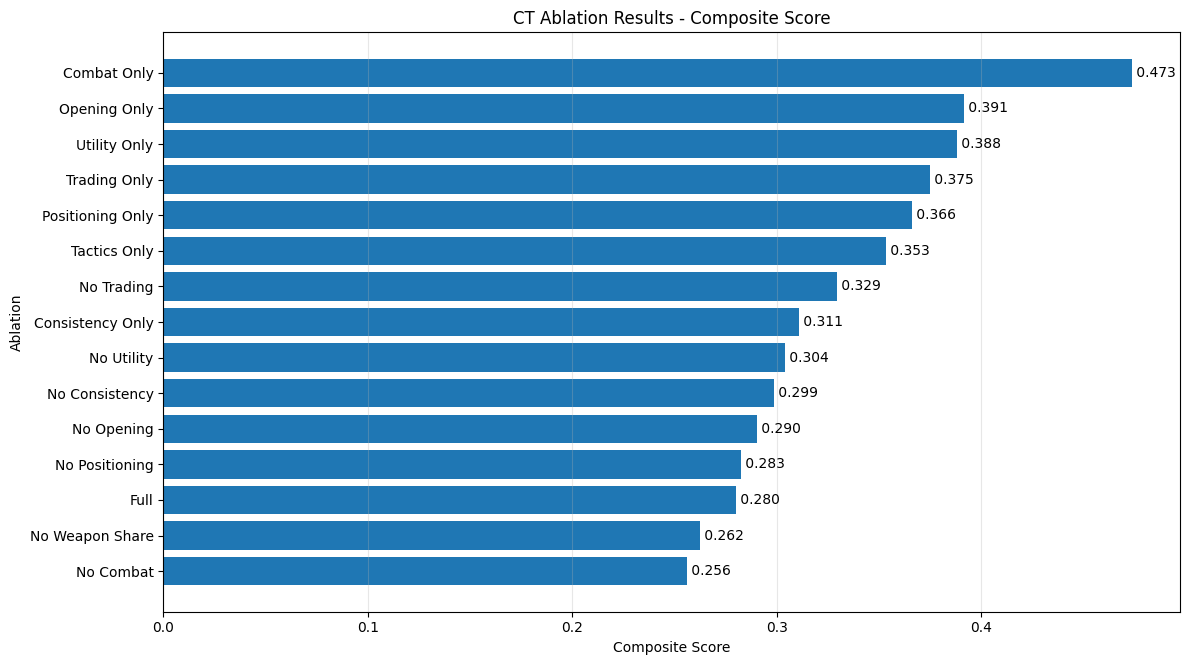

[ok] plots\ablations\ct\ct_composite_score_bar.png


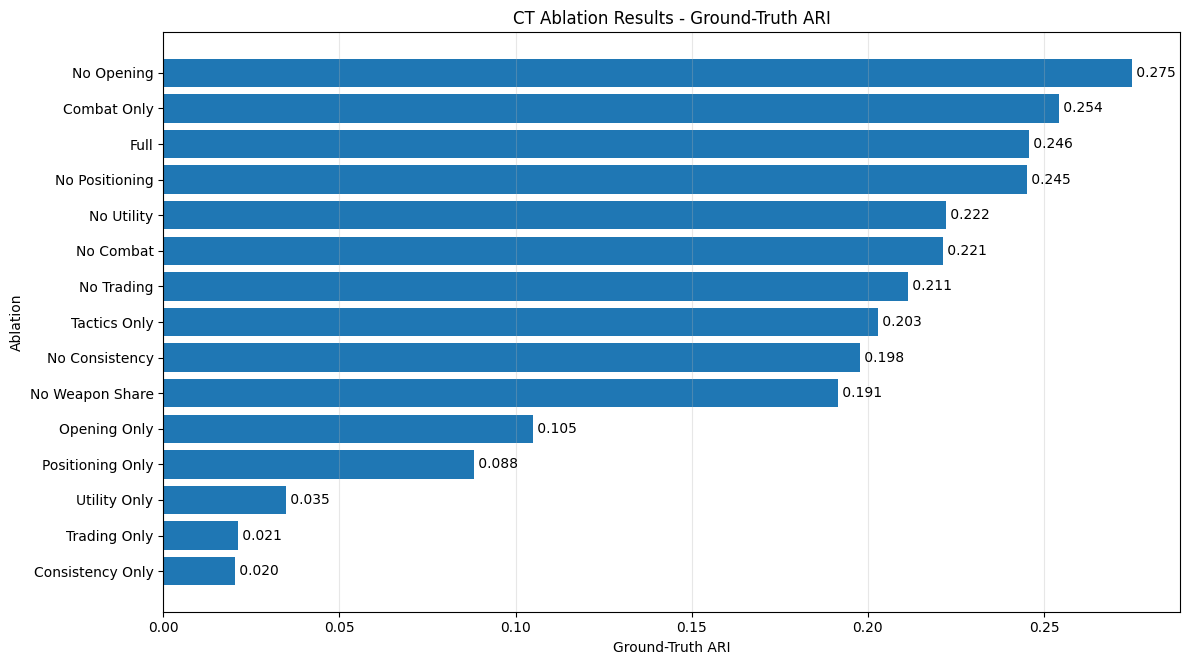

[ok] plots\ablations\ct\ct_gt_ari_bar.png


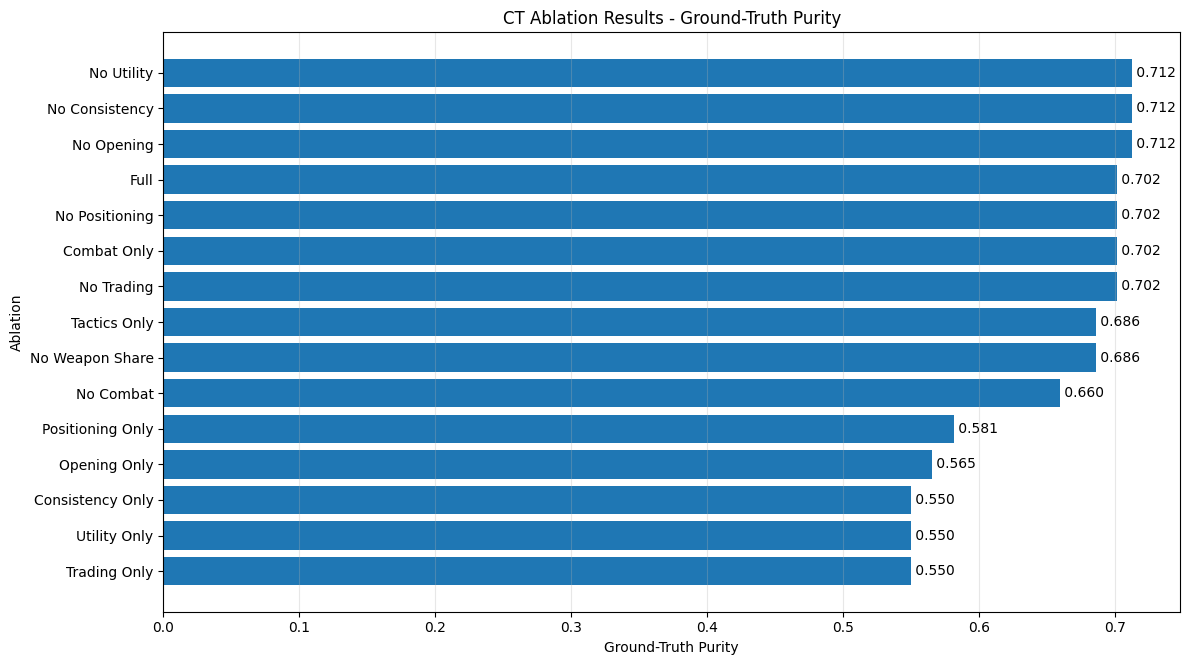

[ok] plots\ablations\ct\ct_gt_purity_bar.png


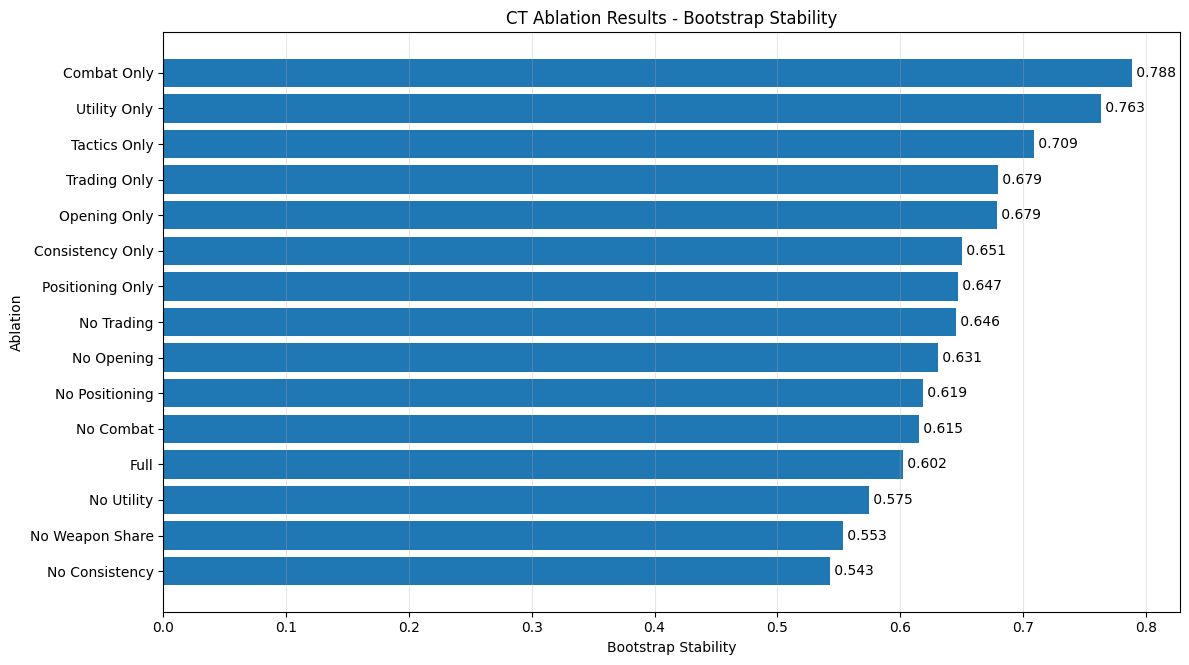

[ok] plots\ablations\ct\ct_stability_mean_bar.png


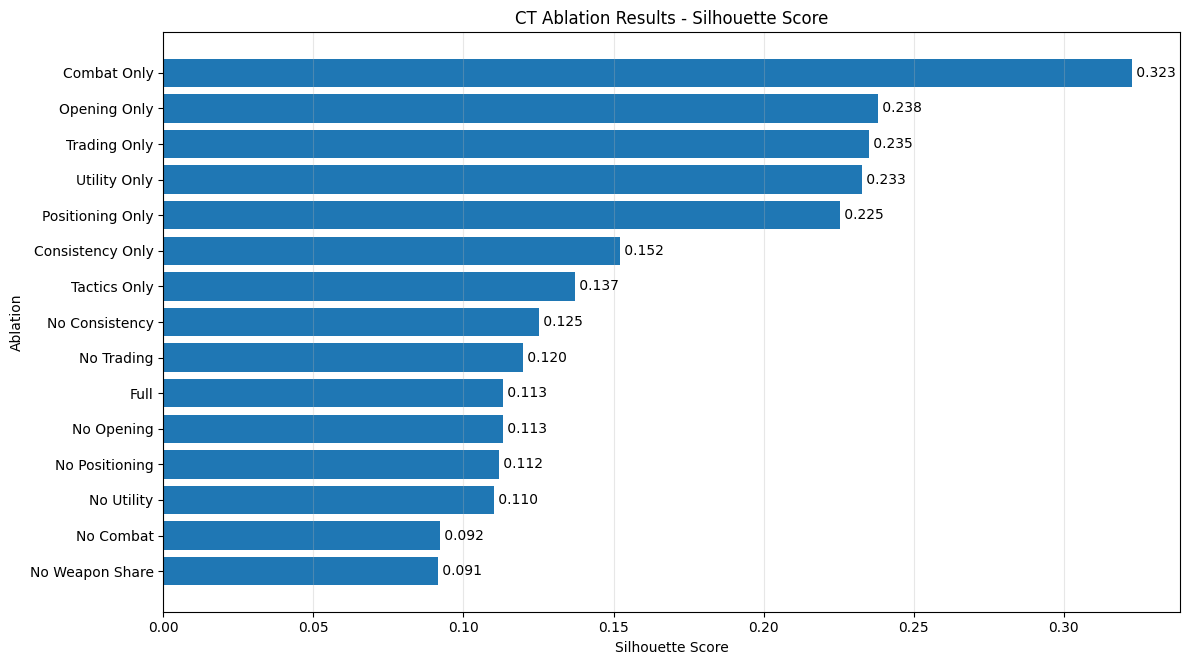

[ok] plots\ablations\ct\ct_silhouette_bar.png


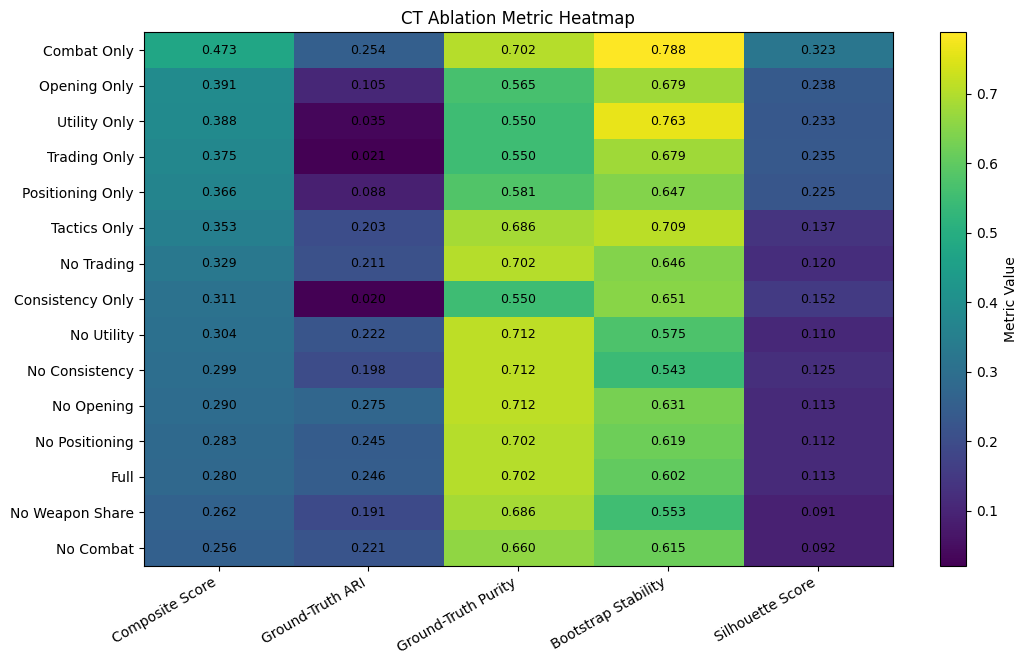

[ok] plots\ablations\ct\ct_metric_heatmap.png


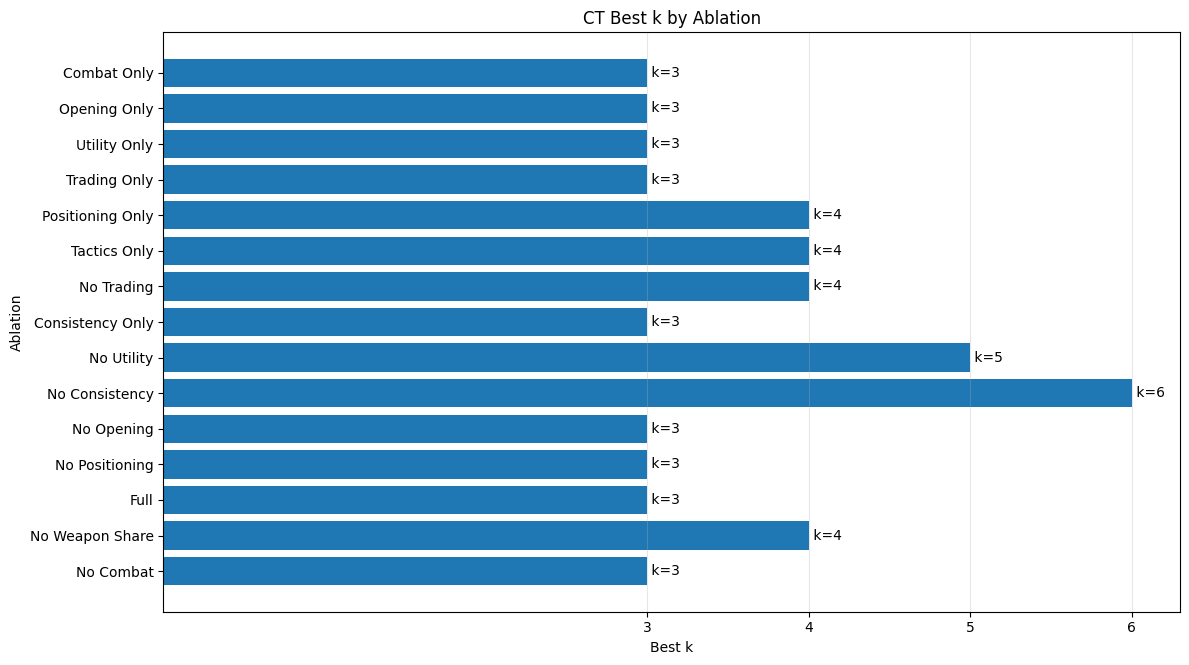

[ok] plots\ablations\ct\ct_best_k.png


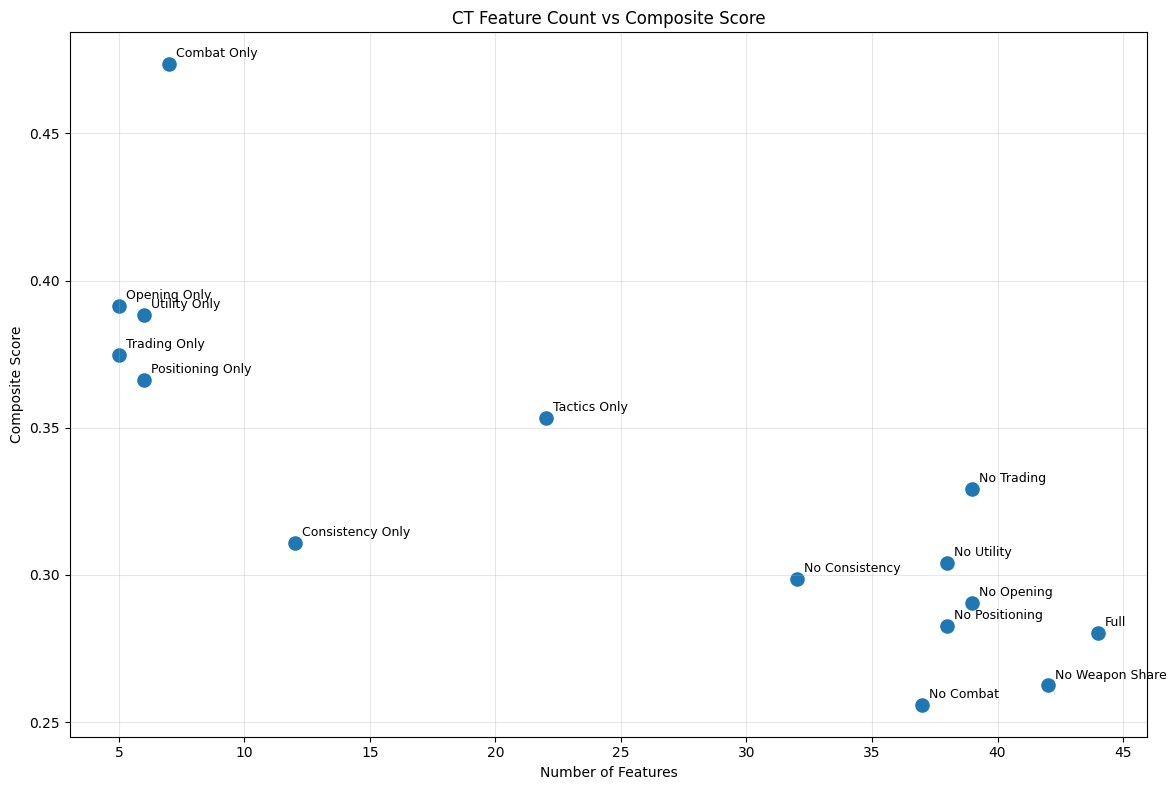

[ok] plots\ablations\ct\ct_feature_count_vs_score.png


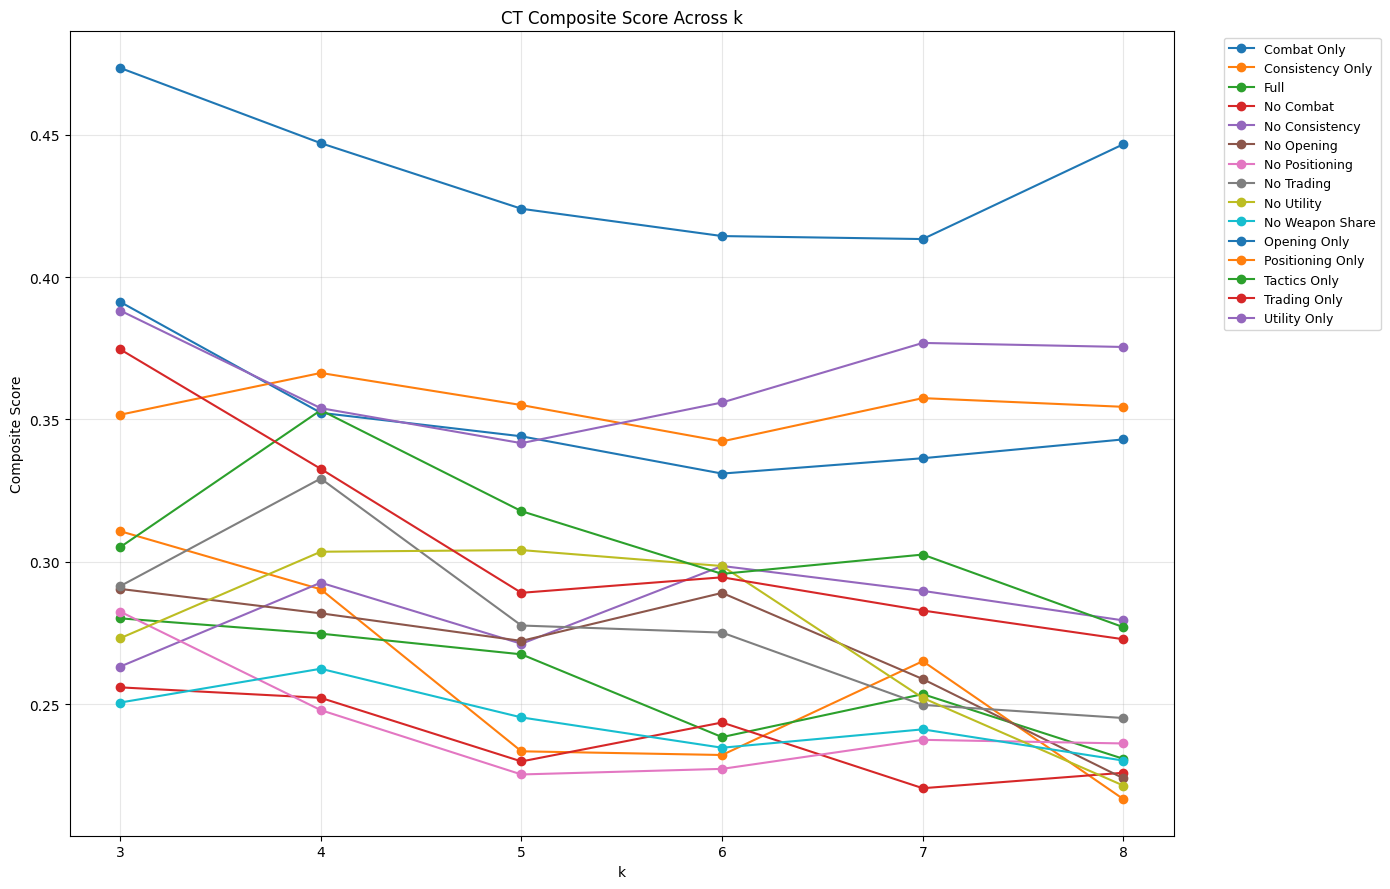

[ok] plots\ablations\ct\ct_composite_by_k.png

=== T Ablation Plots ===


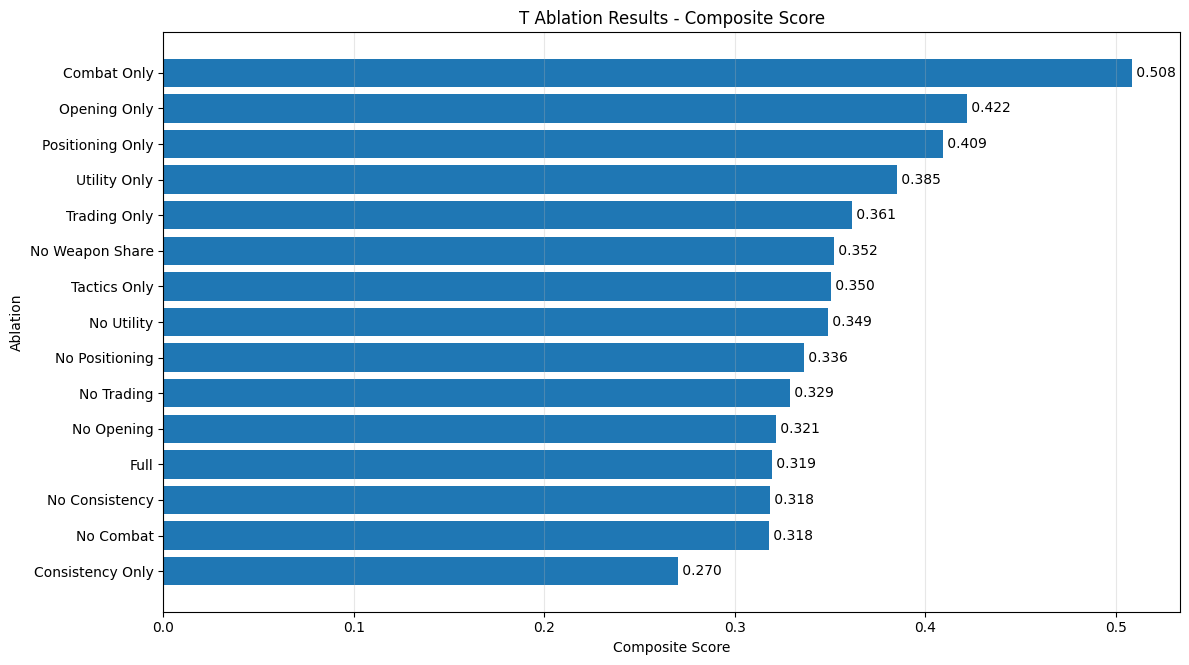

[ok] plots\ablations\t\t_composite_score_bar.png


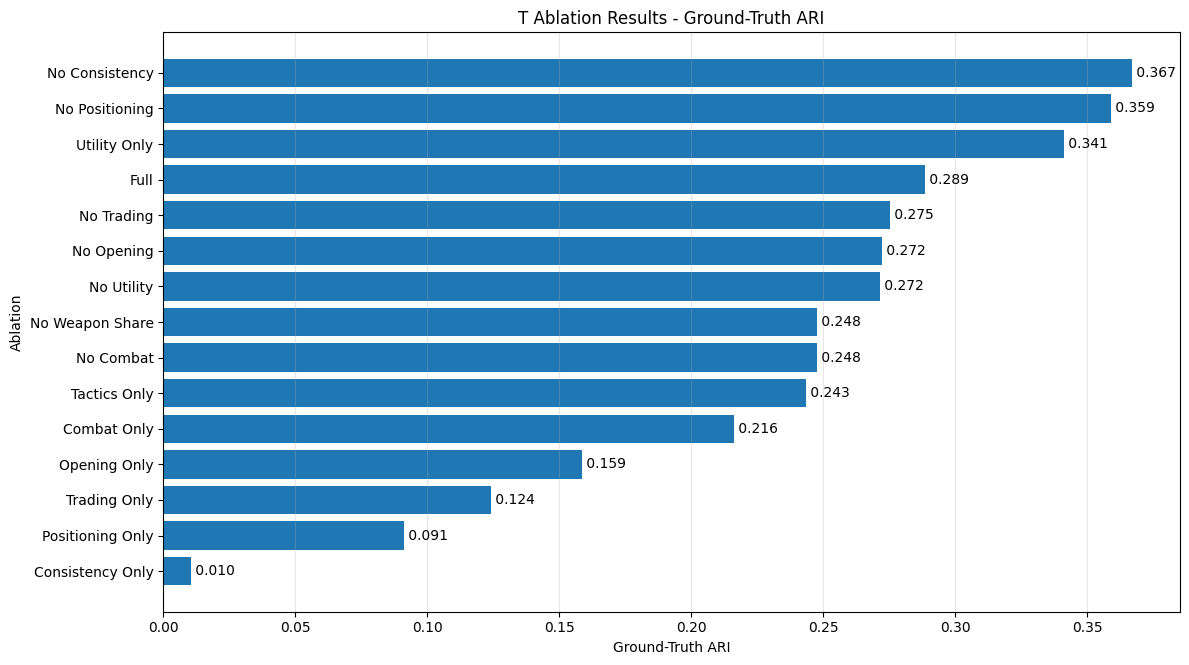

[ok] plots\ablations\t\t_gt_ari_bar.png


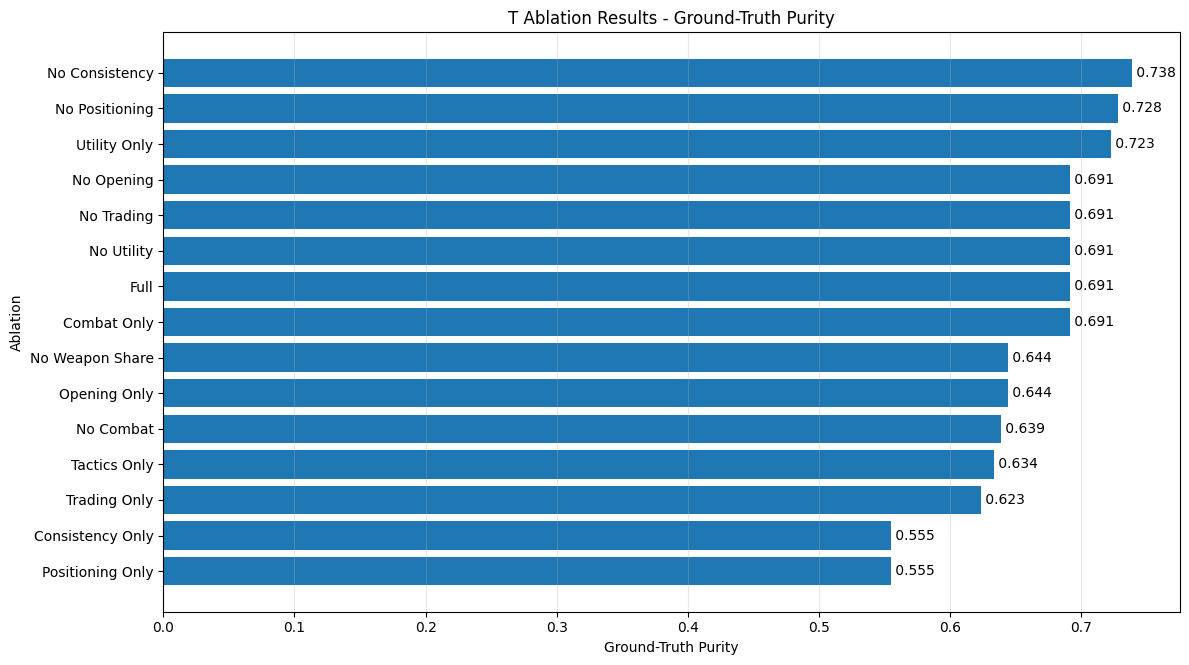

[ok] plots\ablations\t\t_gt_purity_bar.png


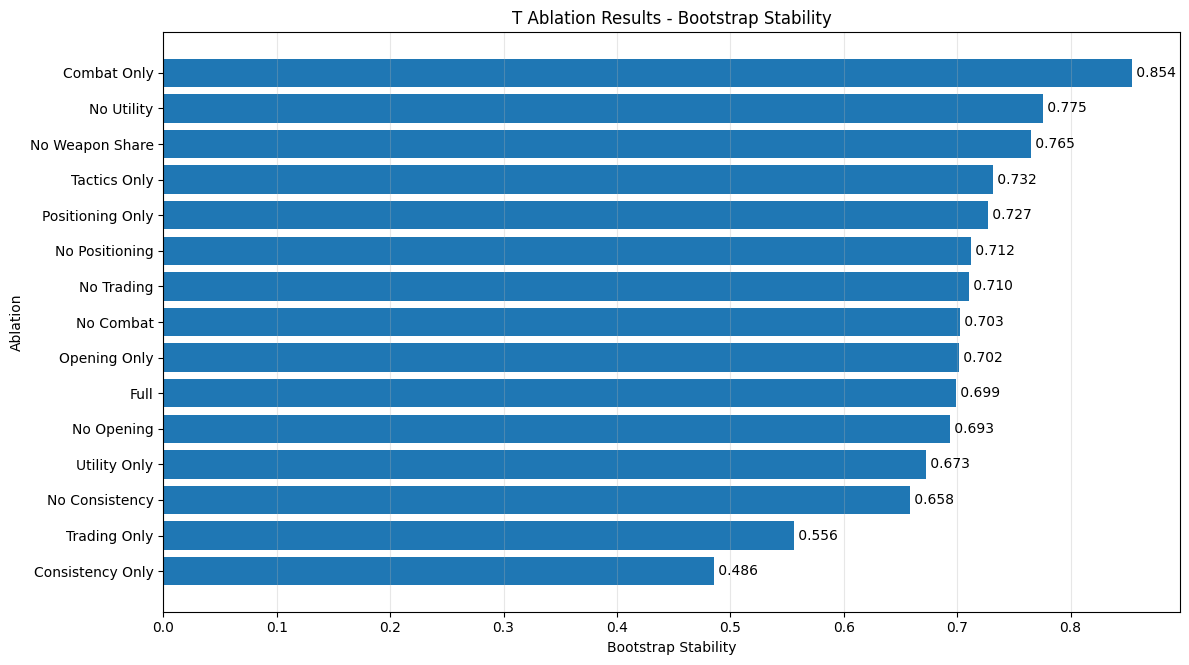

[ok] plots\ablations\t\t_stability_mean_bar.png


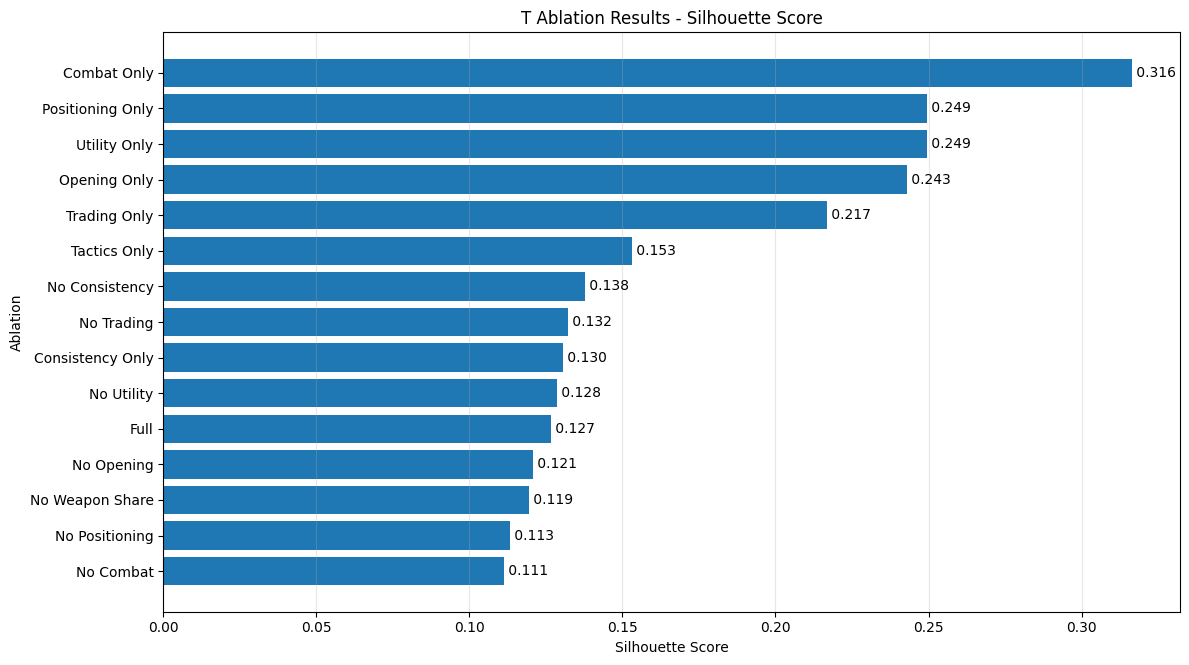

[ok] plots\ablations\t\t_silhouette_bar.png


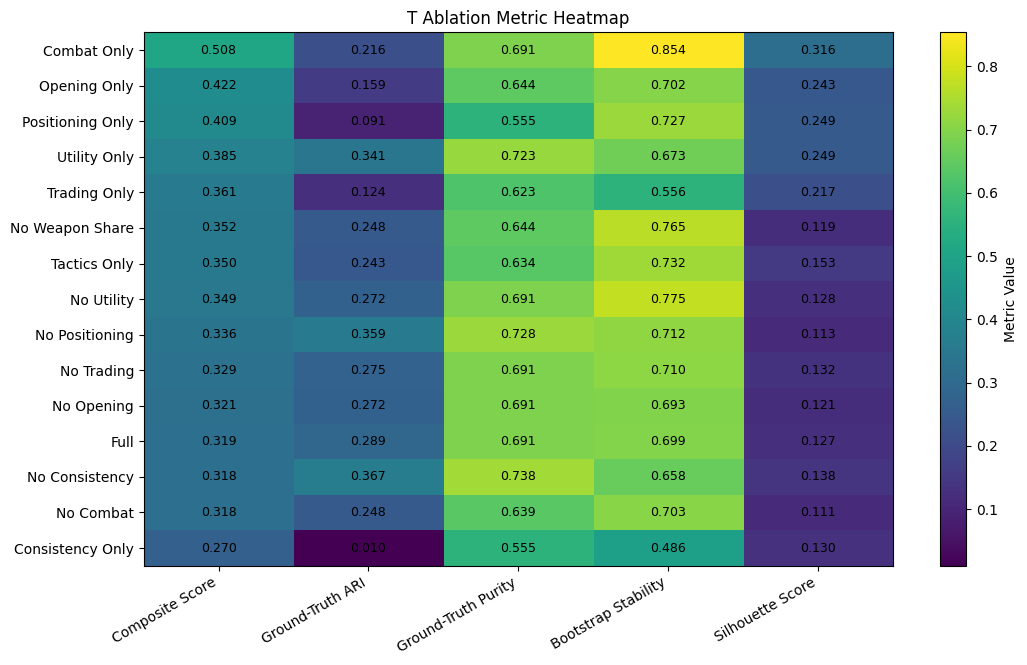

[ok] plots\ablations\t\t_metric_heatmap.png


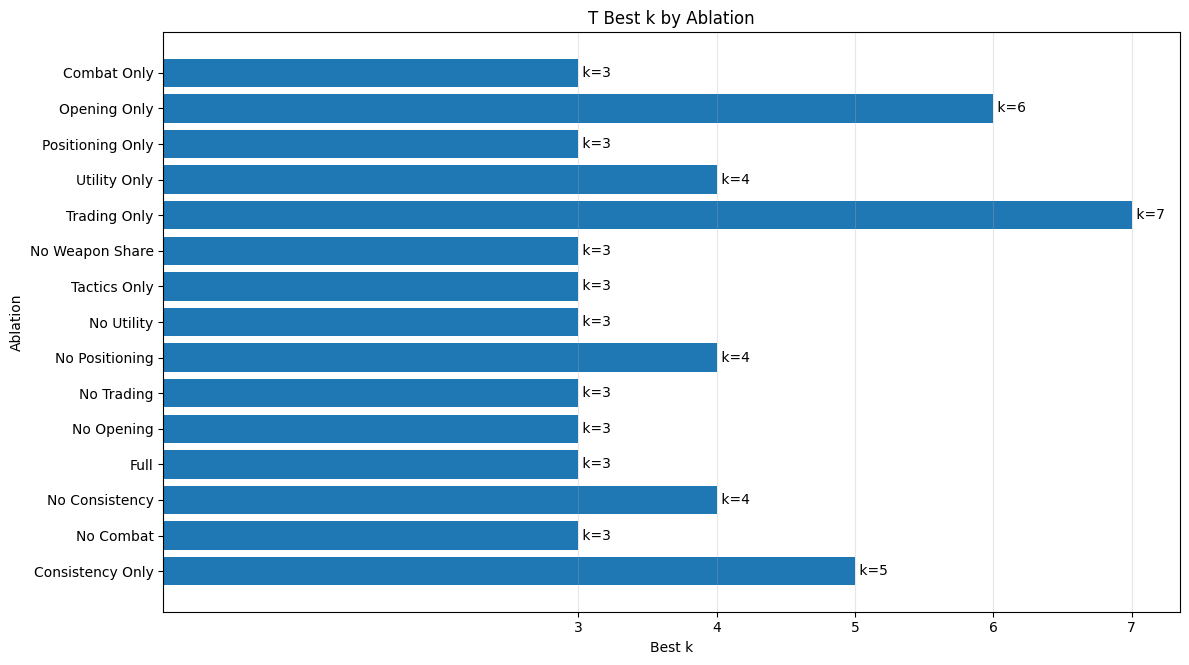

[ok] plots\ablations\t\t_best_k.png


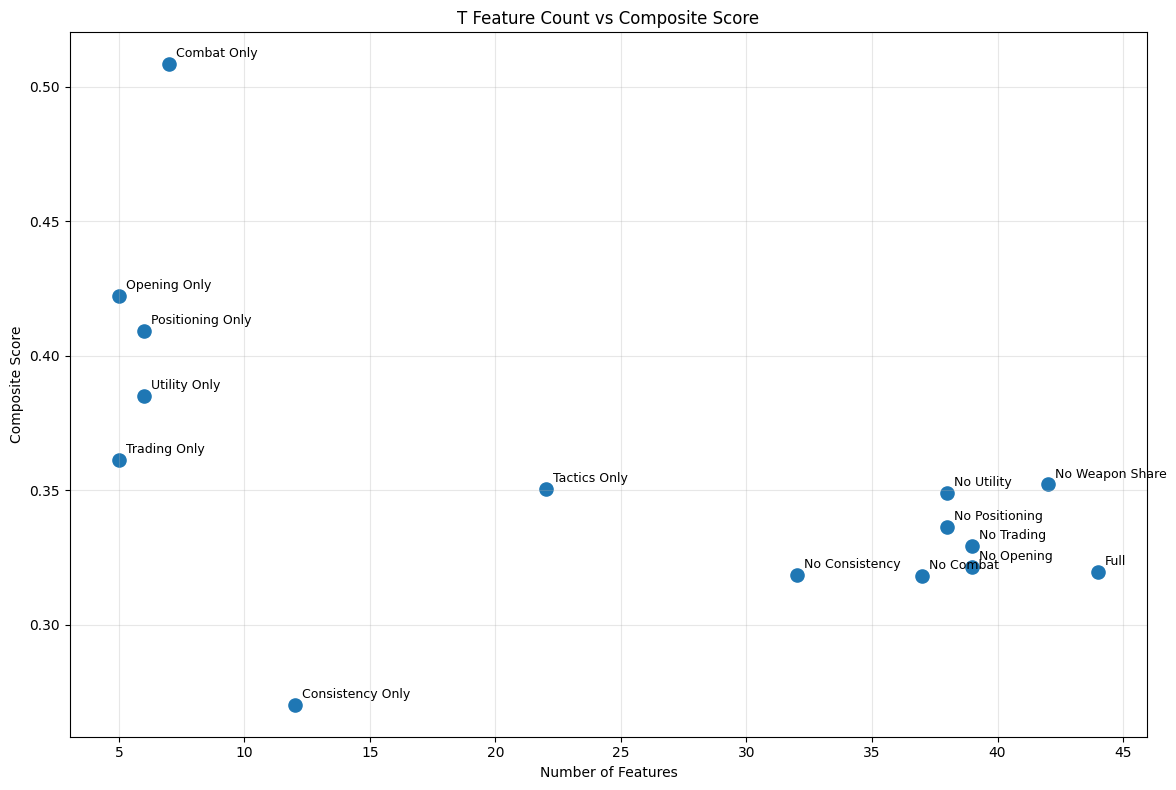

[ok] plots\ablations\t\t_feature_count_vs_score.png


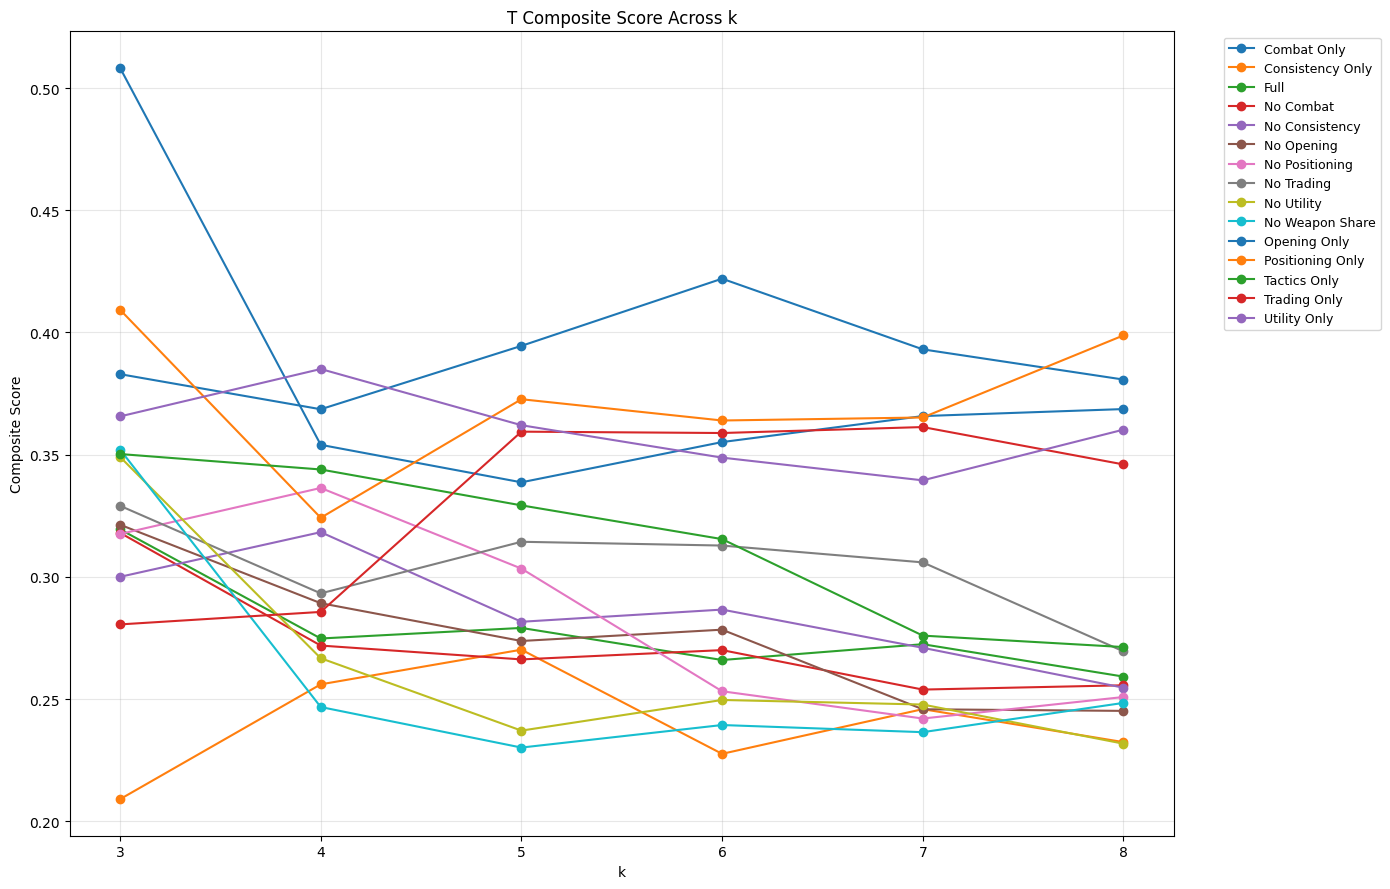

[ok] plots\ablations\t\t_composite_by_k.png


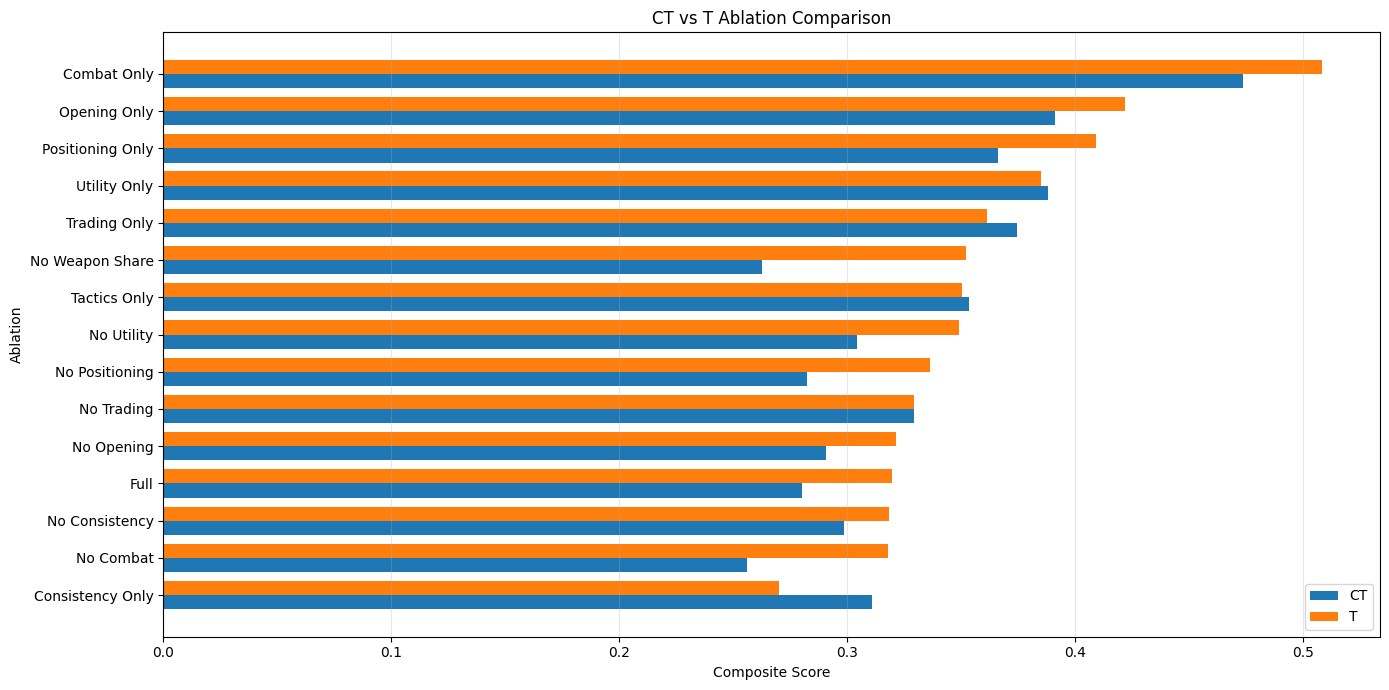

[ok] plots\ablations\ct_vs_t_composite_comparison.png

[done] ablation plots saved in plots\ablations


In [11]:
make_all_ablation_plots()


## Selected ablation inspection

Use this section to rerun one best ablation, save player assignments, save cluster summaries, and create a PCA inspection plot.


In [12]:
def get_best_ablation_row(side: str, ablation: str) -> pd.Series:
    path = ABLATION_OUTPUT_DIR / side / "ablation_results_best.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run ablations first.")
    results = pd.read_csv(path)
    match = results[results["ablation"] == ablation]
    if match.empty:
        available = sorted(results["ablation"].unique())
        raise ValueError(f"Ablation '{ablation}' not found for {side}. Available: {available}")
    return match.iloc[0]


def parse_feature_list(row: pd.Series) -> list[str]:
    features = str(row["features"]).split(", ")
    return [f for f in features if f]


def build_cluster_summary(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    rows = []
    for cluster_id, group in df.groupby("cluster"):
        row = {
            "cluster": cluster_id,
            "n_players": len(group),
            "players": ", ".join(group["player_name"].astype(str).sort_values()),
        }
        for feature in features:
            row[f"{feature}_mean"] = group[feature].mean()
        rows.append(row)
    return pd.DataFrame(rows).sort_values("cluster")


def plot_ablation_clusters(df: pd.DataFrame, side: str, ablation: str) -> None:
    plot_dir = INSPECTION_PLOTS_DIR / side
    plot_dir.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=(14, 10))
    scatter = ax.scatter(df["pc1"], df["pc2"], c=df["cluster"], s=90, cmap="tab10")
    for _, row in df.iterrows():
        ax.annotate(row["player_name"], (row["pc1"], row["pc2"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
    handles, _ = scatter.legend_elements(prop="colors")
    cluster_ids = sorted(df["cluster"].unique())
    ax.legend(handles, [f"Cluster {c}" for c in cluster_ids], title="Cluster", loc="best")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"{side.upper()} Ablated Clusters - {ablation}")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    out = plot_dir / f"{ablation}_clusters_pca.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")
    plt.show()
    print(f"[ok] PCA plot: {out}")


def run_selected_ablation(side: str, ablation: str) -> pd.DataFrame:
    df = load_data()
    side_df = df[df["side"] == side].reset_index(drop=True)
    row = get_best_ablation_row(side, ablation)
    k = int(row["k"])
    features = [f for f in parse_feature_list(row) if f in side_df.columns]
    if len(features) < 2:
        raise ValueError(f"Too few valid features for {side} {ablation}: {features}")

    X = side_df[features].apply(pd.to_numeric, errors="coerce").fillna(0)
    X = X.loc[:, X.nunique() > 1]
    X_scaled = StandardScaler().fit_transform(X)
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit_predict(X_scaled)
    coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)

    out = side_df.copy()
    out["cluster"] = labels
    out["pc1"] = coords[:, 0]
    out["pc2"] = coords[:, 1]
    out["ablation"] = ablation
    out["k"] = k

    side_out_dir = INSPECTION_OUTPUT_DIR / side
    side_out_dir.mkdir(parents=True, exist_ok=True)
    out_path = side_out_dir / f"{ablation}_clusters.csv"
    out.to_csv(out_path, index=False)

    summary = build_cluster_summary(out, X.columns.tolist())
    summary_path = side_out_dir / f"{ablation}_cluster_summary.csv"
    summary.to_csv(summary_path, index=False)

    plot_ablation_clusters(out, side, ablation)
    print(f"[ok] cluster assignments: {out_path}")
    print(f"[ok] cluster summary:     {summary_path}")
    return out


def print_cluster_players(df: pd.DataFrame) -> None:
    for cluster_id, group in df.groupby("cluster"):
        players = group["player_name"].astype(str).sort_values().tolist()
        print(f"\nCluster {cluster_id} | n={len(players)}")
        print(", ".join(players))


### Inspect one ablation


In [13]:
# Example:
# selected = run_selected_ablation(side="t", ablation="no_weapon_share")
# print_cluster_players(selected)
